In [3]:
### Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
### load diabetes dataset 
df=pd.read_csv('diabetes.csv')
df.head(4)

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy


In [5]:
## checking shape pf the dataset
df.shape

(6000, 6)

In [6]:
##Basic information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             6000 non-null   int64  
 1    age           6000 non-null   float64
 2    systolic_bp   6000 non-null   float64
 3    diastolic_bp  6000 non-null   float64
 4    cholesterol   6000 non-null   float64
 5    prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


#### From this information we can see that the provoded dataset contains 5 numerical columns and 1 categorical column

In [7]:
### getting the column names of the dataset
df.columns

Index(['ID', ' age', ' systolic_bp ', ' diastolic_bp', ' cholesterol',
       ' prognosis'],
      dtype='object')

In [8]:
### Dropping the ID column which is as same as the index in the dataset
df.drop(columns=['ID'],inplace=True)
df.head()

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [9]:
### Getting the statistical summary of the dataset
df.describe()

,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,60.464121,100.694822,90.505547,100.628255
std,8.564392,10.669267,9.648200,10.433915
min,35.164761,69.675429,62.807105,69.967453
25%,54.371941,93.267420,83.641788,93.202373
50%,59.831159,100.119926,89.912429,100.060637
75%,65.809652,107.439501,96.682405,107.250829
max,103.279497,151.699660,133.456382,148.233544


### The statistcal summary is calculated only for the numeric data, hence we need to convert the target to numeric type for computation

In [10]:
### Checking for missing values
df.isnull().sum()

age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64

### Hence there are no missing values in the diabetes dataset

In [11]:
### Checking for duplicates
df.duplicated().sum()

np.int64(0)

### Hence there are no duplicate values present in the given dataset

In [12]:
### Separating Target and features
target= df[[' prognosis']]
features= df.drop(columns=[' prognosis'])

In [13]:
## As the Target column is categorical, we need to apply labelling to the prognosis column
from sklearn.preprocessing import LabelEncoder,StandardScaler
enc=LabelEncoder()

In [14]:
y=pd.DataFrame(enc.fit_transform(target),columns=['Target'])
y.head()

,Target
0,1
1,1
2,1
3,1
4,1


In [15]:
### Statistical summary of the target column
y.describe()

,Target
count,6000.000000
mean,0.514500
std,0.499831
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [16]:
### Getting the number of yes and no in the prognosis(Target column)
y.value_counts()

Target
1         3087
0         2913
Name: count, dtype: int64

#### DATA VISUALIZATION

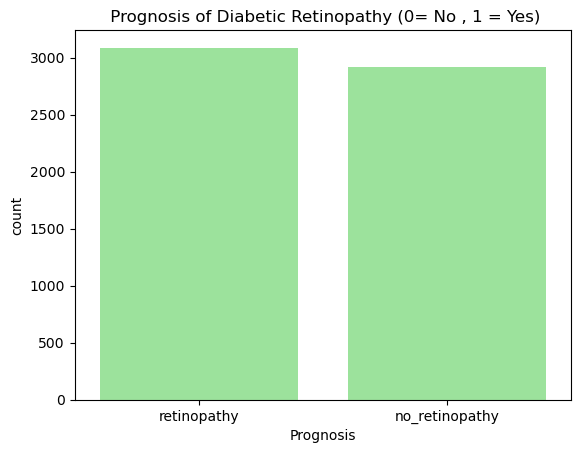

In [17]:
### Visualizing the distribution of Target Varibale(Prognosis)
sns.countplot(x=' prognosis',data=df,color='Lightgreen')
plt.title(' Prognosis of Diabetic Retinopathy (0= No , 1 = Yes)')
plt.xlabel('Prognosis')
plt.ylabel('count')
plt.show()

### plotting visualizations for feature columns

In [18]:
df.columns

Index([' age', ' systolic_bp ', ' diastolic_bp', ' cholesterol', ' prognosis'], dtype='object')

### Histogram plt for Feature distributions

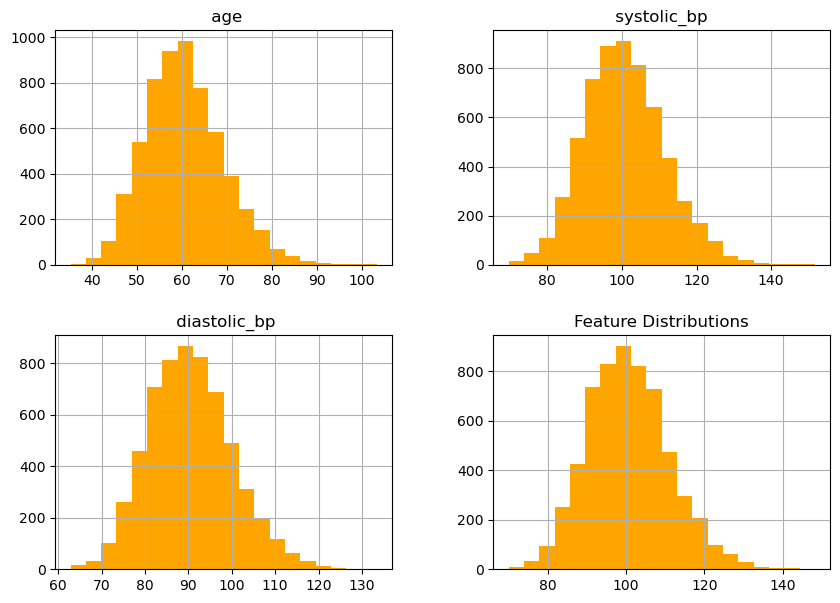

In [19]:
df.hist(figsize=(10,7),bins=20,color='Orange')
plt.title('Feature Distributions')
plt.show()

In [20]:
### Plotting boxplots for each feature versus prognosis

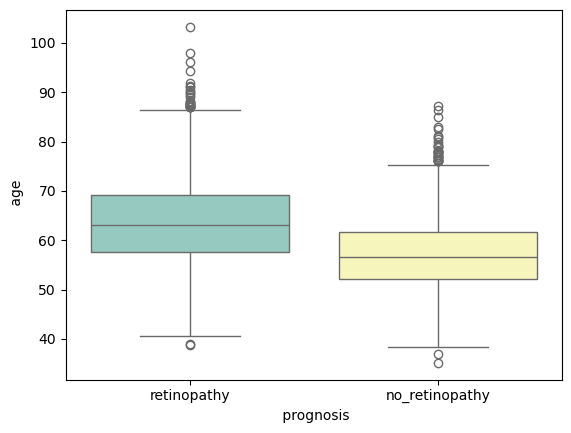

In [21]:
sns.boxplot(x=' prognosis',y=' age',data=df, palette= 'Set3')
plt.show()

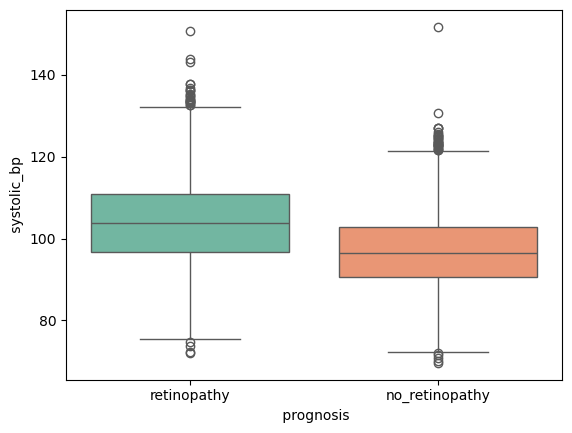

In [22]:
sns.boxplot(x=' prognosis',y= ' systolic_bp ',data=df, palette= 'Set2')
plt.show()

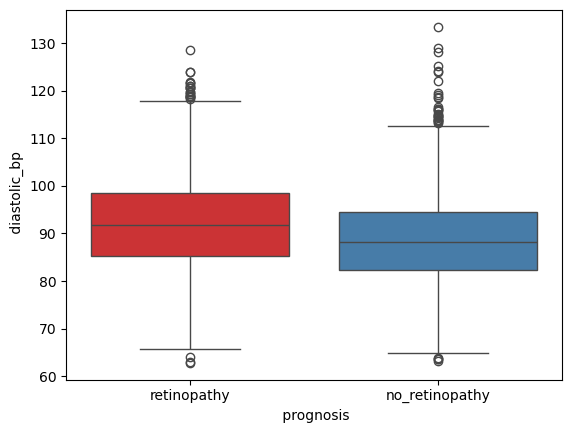

In [23]:
sns.boxplot(x=' prognosis',y= ' diastolic_bp',data=df, palette= 'Set1')
plt.show()

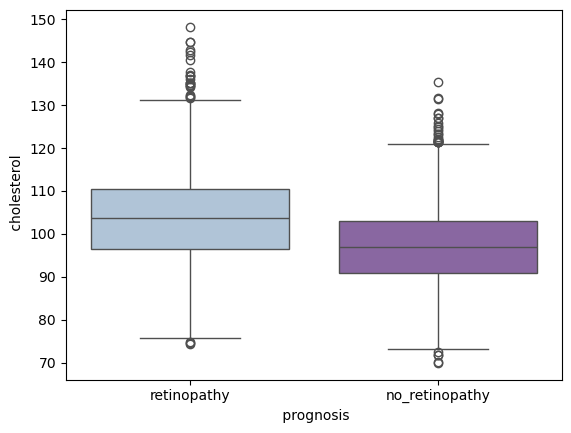

In [24]:
sns.boxplot(x=' prognosis',y= ' cholesterol',data=df, palette= 'BuPu')
plt.show()

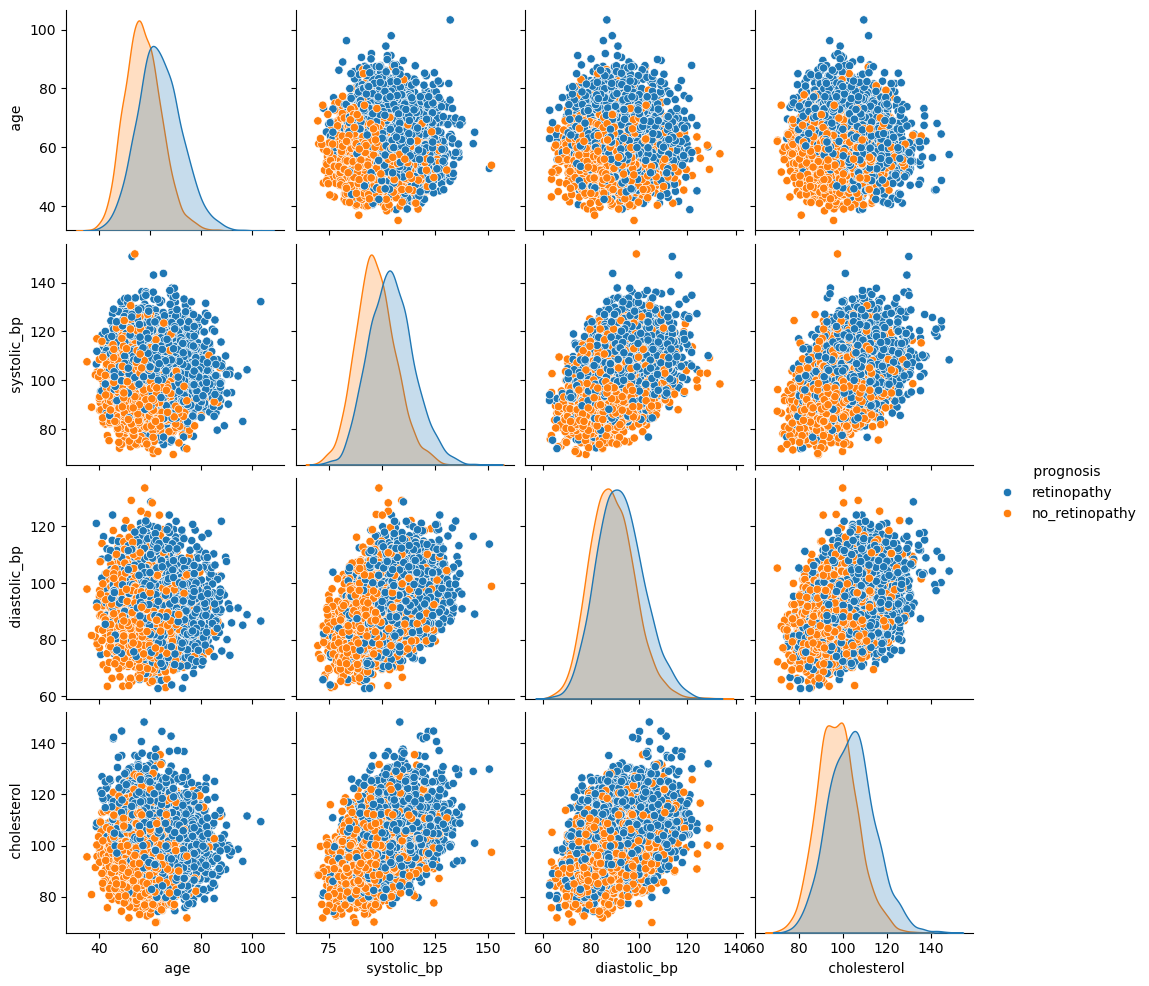

In [25]:
### Pairplot for representing the relationship of numerical variable with target 
sns.pairplot(df,hue=' prognosis')
plt.show()

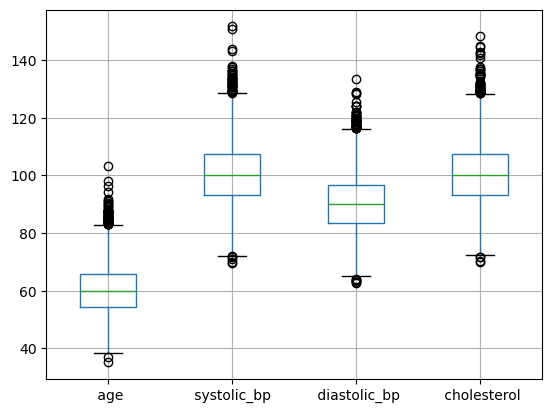

In [26]:
### checking for outliers in features
features.boxplot()
plt.show()

In [27]:
### Applying capping technique to remove outliers
def outlier_cappping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in features.select_dtypes(['int','float']).columns:

    outlier_cappping(features,col)


<Axes: >

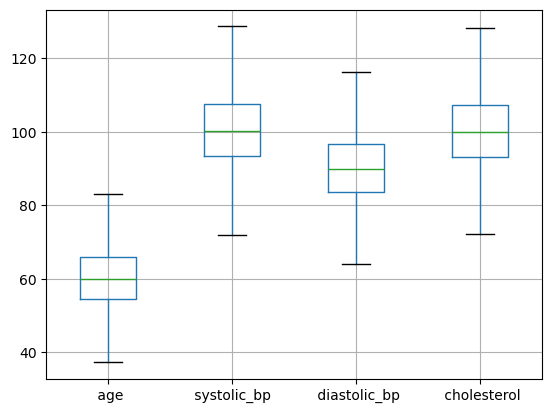

In [28]:
features.boxplot()

#### Hence outliers are removed from the features

#### Finding the correlation between the variables


In [29]:
features.columns

Index([' age', ' systolic_bp ', ' diastolic_bp', ' cholesterol'], dtype='object')

In [30]:
f1=features.copy()

In [31]:
f1['Diagnosis']=y
f1.head()

,age,systolic_bp,diastolic_bp,cholesterol,Diagnosis
0,77.196340,85.288742,80.021878,79.957109,1
1,63.529850,99.379736,84.852361,110.382411,1
2,69.003986,111.349455,109.850616,100.828246,1
3,82.638210,95.056128,79.666851,87.066303,1
4,78.346286,109.154591,90.713220,92.511770,1


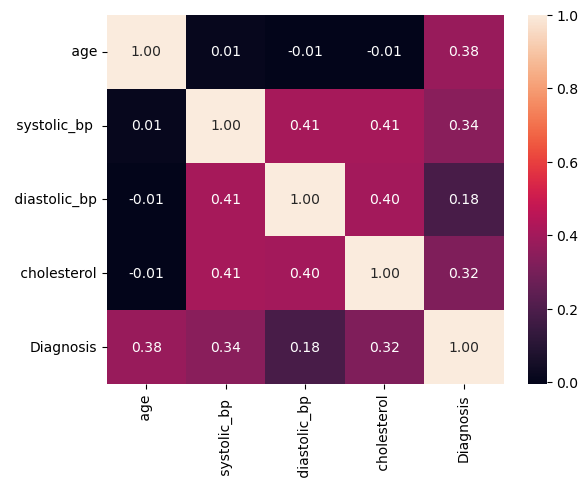

In [32]:
sns.heatmap(f1.corr(),annot=True,cmap='rocket',fmt='.2f')
plt.show()

In [33]:
# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'skew': features.skew(),
    'kurtosis': features.kurt()
})
skew_kurt

,skew,kurtosis
age,0.334543,-0.139277
systolic_bp,0.247914,-0.126076
diastolic_bp,0.262640,-0.115869
cholesterol,0.263070,-0.122688


In [34]:
### applying scaling to the numerical columns
scaler=StandardScaler()

In [35]:
X=scaler.fit_transform(features)
X

array([[ 1.98780321, -1.45758536, -1.09476087, -2.00360948],
       [ 0.36809089, -0.12108382, -0.58884773,  0.95146283],
       [ 1.01686947,  1.01421926,  2.02930567,  0.02350989],
       ...,
       [-0.57620663, -0.2119756 ,  1.2801745 ,  1.97065303],
       [ 0.36087392,  0.58359391, -0.25283452,  0.53089025],
       [ 0.24684488, -0.35620729, -0.37669204,  0.78081579]])

In [36]:
#### Verifying the Standardization applied to the numerial values in the dataset
print(np.mean(X,axis=0))
print(np.std(X,axis=0))

[ 8.19492622e-16  8.76336041e-17 -9.94759830e-16  7.10246676e-16]
[1. 1. 1. 1.]


In [37]:
### Splitting the dataset in train and test
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4800, 4)
(1200, 4)
(4800, 1)
(1200, 1)


In [41]:
print(X_train.columns.tolist())

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

###   Building the models

In [37]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score,roc_curve

In [38]:
### Defining an evaluation function
def eval_model(y,yhat):
    cm=confusion_matrix(y,yhat)
    
    plt.figure(figsize=(4,2))
    sns.heatmap(cm,cmap='coolwarm',annot=True,fmt='d')
    plt.title('Confusion Matrix')
    plt.show()
    
    print('Accuracy_score:',accuracy_score(y,yhat))
    print('Precision_Score:',precision_score(y,yhat))           
    print('Recall_score:',recall_score(y,yhat))
    print ('f1_score:',f1_score(y,yhat))
    print('Classification report:',classification_report(y,yhat))
        

## 1.Logistic Regression Model

In [39]:
log_reg=LogisticRegression(max_iter=400)

In [40]:
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=400)

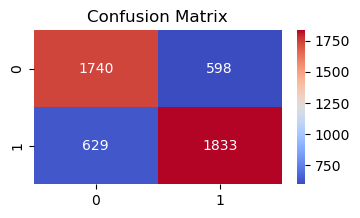

Accuracy_score: 0.744375
Precision_Score: 0.7540106951871658
Recall_score: 0.7445166531275386
f1_score: 0.7492335990190068
Classification report:               precision    recall  f1-score   support

           0       0.73      0.74      0.74      2338
           1       0.75      0.74      0.75      2462

    accuracy                           0.74      4800
   macro avg       0.74      0.74      0.74      4800
weighted avg       0.74      0.74      0.74      4800



In [41]:
### Predicting the model on training and testing data
yhat_train1=log_reg.predict(X_train)
eval_model(y_train,yhat_train1)

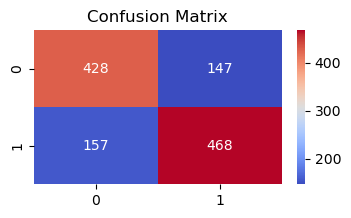

Accuracy_score: 0.7466666666666667
Precision_Score: 0.7609756097560976
Recall_score: 0.7488
f1_score: 0.7548387096774194
Classification report:               precision    recall  f1-score   support

           0       0.73      0.74      0.74       575
           1       0.76      0.75      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [42]:
yhat_test1=log_reg.predict(X_test)
y_prob1=log_reg.predict_proba(X_test)[:,1]
eval_model(y_test,yhat_test1)

In [43]:
### Calculating AUC-ROC score for Logistic Regression model
auc_score1=roc_auc_score(y_test,y_prob1)
print("AUC_ROC_SCORE of logistic regression model is:",auc_score1)

AUC_ROC_SCORE of logistic regression model is: 0.8284215652173914


### 2.XGBClassifier
Here we can perform hyperparameter tuning so as to get the best values of the model parameters

In [44]:
xgb=XGBClassifier(n_estimators=20,max_depth=2)

In [45]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=20,
              n_jobs=None, num_parallel_tree=None, ...)

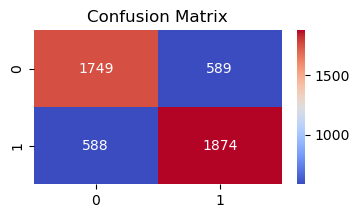

Accuracy_score: 0.7547916666666666
Precision_Score: 0.7608607389362566
Recall_score: 0.7611697806661251
f1_score: 0.7610152284263959
Classification report:               precision    recall  f1-score   support

           0       0.75      0.75      0.75      2338
           1       0.76      0.76      0.76      2462

    accuracy                           0.75      4800
   macro avg       0.75      0.75      0.75      4800
weighted avg       0.75      0.75      0.75      4800



In [46]:
## Evaluating model on training and testing data
yhat_train2= xgb.predict(X_train)
eval_model(y_train,yhat_train2)

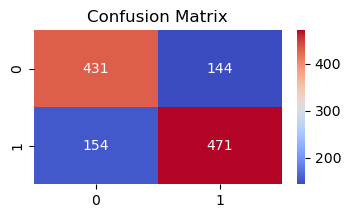

Accuracy_score: 0.7516666666666667
Precision_Score: 0.7658536585365854
Recall_score: 0.7536
f1_score: 0.7596774193548387
Classification report:               precision    recall  f1-score   support

           0       0.74      0.75      0.74       575
           1       0.77      0.75      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [47]:
yhat_test2= xgb.predict(X_test)
y_prob2=xgb.predict_proba(X_test)[:,1]

eval_model(y_test,yhat_test2)

In [48]:
### Calculating AUC-ROC score for XGboost model
auc_score2=roc_auc_score(y_test,y_prob2)
print("AUC_ROC_SCORE of XGBoost Classifier model is:",auc_score2)

AUC_ROC_SCORE of XGBoost Classifier model is: 0.8252229565217392


In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
params={
    'n_estimators':[50.100,150,20],
    'max_depth':[2,4,5,7,9,12,24],
    'min_sample_split':[4,5,6,8,9,10]
}     

In [51]:
grid=GridSearchCV(xgb,cv=5,param_grid=params)

In [52]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=20,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [2, 4, 5, 7, 9, 12, 24],
                         'min_sample_split': [4, 5, 6, 8, 9, 10],
                         'n_estimators': [50.1, 150, 20]})

In [53]:
grid.best_params_

{'max_depth': 2, 'min_sample_split': 4, 'n_estimators': 20}

### 3. LightGBM Classifier

In [54]:
lgb=LGBMClassifier(n_estimators=20,max_depth=4)                   

In [55]:
### Training the model
lgb.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 2462, number of negative: 2338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 4800, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512917 -> initscore=0.051678
[LightGBM] [Info] Start training from score 0.051678
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMClassifier(max_depth=4, n_estimators=20)

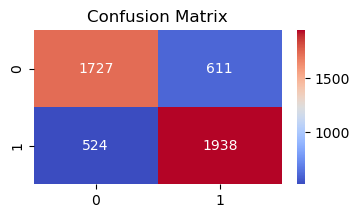

Accuracy_score: 0.7635416666666667
Precision_Score: 0.7602981561396626
Recall_score: 0.7871649065800163
f1_score: 0.7734983037317901
Classification report:               precision    recall  f1-score   support

           0       0.77      0.74      0.75      2338
           1       0.76      0.79      0.77      2462

    accuracy                           0.76      4800
   macro avg       0.76      0.76      0.76      4800
weighted avg       0.76      0.76      0.76      4800



In [56]:
###Evaluating the model on training and testing data
yhat_train3=lgb.predict(X_train)
eval_model(y_train,yhat_train3)

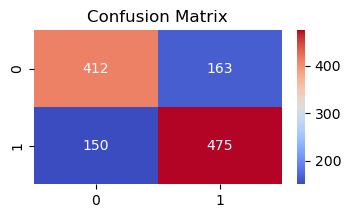

Accuracy_score: 0.7391666666666666
Precision_Score: 0.7445141065830722
Recall_score: 0.76
f1_score: 0.7521773555027712
Classification report:               precision    recall  f1-score   support

           0       0.73      0.72      0.72       575
           1       0.74      0.76      0.75       625

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



In [57]:
### Evaluating model on testing data
yhat_test3=lgb.predict(X_test)
y_prob3=lgb.predict_proba(X_test)[:,1]

eval_model(y_test,yhat_test3)

In [58]:
### Calculating AUC-ROC score for LightGBM model
auc_score3=roc_auc_score(y_test,y_prob3)
print("AUC_ROC_SCORE of lightGBM model is:",auc_score3)

AUC_ROC_SCORE of lightGBM model is: 0.8235617391304348


### 4. SVM Classifier

In [59]:
svm_class=SVC(kernel='rbf',C=1.0,gamma='scale',probability=True)

In [60]:
svm_class.fit(X_train,y_train)

SVC(probability=True)

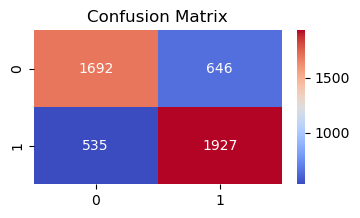

Accuracy_score: 0.7539583333333333
Precision_Score: 0.7489312087057909
Recall_score: 0.7826969943135662
f1_score: 0.765441906653426
Classification report:               precision    recall  f1-score   support

           0       0.76      0.72      0.74      2338
           1       0.75      0.78      0.77      2462

    accuracy                           0.75      4800
   macro avg       0.75      0.75      0.75      4800
weighted avg       0.75      0.75      0.75      4800



In [61]:
### Evaluating model on training and testing data
yhat_train4=svm_class.predict(X_train)
eval_model(y_train,yhat_train4)

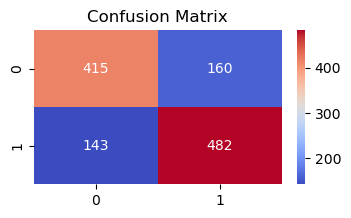

Accuracy_score: 0.7475
Precision_Score: 0.7507788161993769
Recall_score: 0.7712
f1_score: 0.760852407261247
Classification report:               precision    recall  f1-score   support

           0       0.74      0.72      0.73       575
           1       0.75      0.77      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [62]:
yhat_test4=svm_class.predict(X_test)
y_prob4 =svm_class.predict_proba(X_test)[:,1]

eval_model(y_test,yhat_test4)

### 5.GaussianNB

In [63]:
gau_nb=GaussianNB()
gau_nb.fit(X_train,y_train)

GaussianNB()

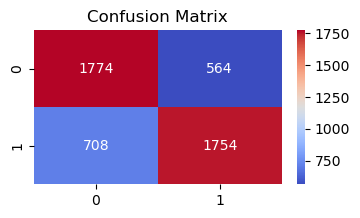

Accuracy_score: 0.735
Precision_Score: 0.7566867989646247
Recall_score: 0.7124289195775793
f1_score: 0.7338912133891213
Classification report:               precision    recall  f1-score   support

           0       0.71      0.76      0.74      2338
           1       0.76      0.71      0.73      2462

    accuracy                           0.73      4800
   macro avg       0.74      0.74      0.73      4800
weighted avg       0.74      0.74      0.73      4800



In [64]:
### Evaluating Guassian Navie Bayes Algorithm on training and testing data
yhat_train5=gau_nb.predict(X_train)
eval_model(y_train,yhat_train5)

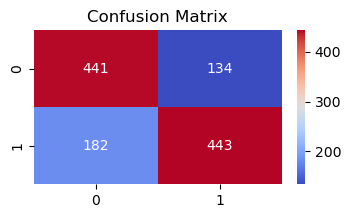

Accuracy_score: 0.7366666666666667
Precision_Score: 0.7677642980935875
Recall_score: 0.7088
f1_score: 0.7371048252911814
Classification report:               precision    recall  f1-score   support

           0       0.71      0.77      0.74       575
           1       0.77      0.71      0.74       625

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



In [65]:
yhat_test5= gau_nb.predict(X_test)
y_prob5= gau_nb.predict_proba(X_test)[:,1]

eval_model(y_test,yhat_test5)

In [66]:
###6. Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [67]:
d_tree=DecisionTreeClassifier(max_depth=5,criterion='entropy',max_leaf_nodes=20)

In [68]:
### Training the model
d_tree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=20)

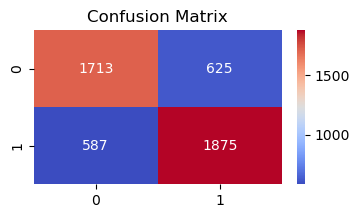

Accuracy_score: 0.7475
Precision_Score: 0.75
Recall_score: 0.7615759545085297
f1_score: 0.7557436517533253
Classification report:               precision    recall  f1-score   support

           0       0.74      0.73      0.74      2338
           1       0.75      0.76      0.76      2462

    accuracy                           0.75      4800
   macro avg       0.75      0.75      0.75      4800
weighted avg       0.75      0.75      0.75      4800



In [69]:
## Evaluating the model
yhat_train6=d_tree.predict(X_train)
eval_model(y_train,yhat_train6)

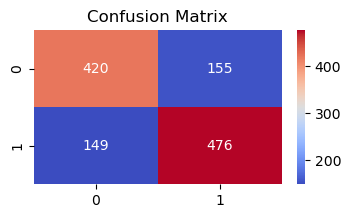

Accuracy_score: 0.7466666666666667
Precision_Score: 0.7543581616481775
Recall_score: 0.7616
f1_score: 0.7579617834394905
Classification report:               precision    recall  f1-score   support

           0       0.74      0.73      0.73       575
           1       0.75      0.76      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [70]:
yhat_test6=d_tree.predict(X_test)
y_prob6=d_tree.predict_proba(X_test)[:,1]

eval_model(y_test,yhat_test6)

In [71]:
### Printing the accuracy scores of all the models

print('Accuracy score of Logisitic Regression model is:',accuracy_score(y_test,yhat_test1))
print('Accuracy score of XGboost Classifier model is:',accuracy_score(y_test,yhat_test2))
print('Accuracy score of Lightgbm Classifier model is:',accuracy_score(y_test,yhat_test3))
print('Accuracy score of SVM Classifier model is:',accuracy_score(y_test,yhat_test4))
print('Accuracy score of Gaussian Navie Bayes model is:',accuracy_score(y_test,yhat_test5))
print('Accuracy score of Decision Tree model is:',accuracy_score(y_test,yhat_test6))



Accuracy score of Logisitic Regression model is: 0.7466666666666667
Accuracy score of XGboost Classifier model is: 0.7516666666666667
Accuracy score of Lightgbm Classifier model is: 0.7391666666666666
Accuracy score of SVM Classifier model is: 0.7475
Accuracy score of Gaussian Navie Bayes model is: 0.7366666666666667
Accuracy score of Decision Tree model is: 0.7466666666666667


In [72]:
### Getting predicted Probabilit vales of all postitive classes from all models

In [73]:
print('Predicted probabilities for the positive classes')
print('Prob of Logistic model:',y_prob1)
print('Prob of XGboost model:',y_prob2)
print('Prob of LightGBM model:',y_prob3)
print('Prob of SVM model:',y_prob4)
print('Prob of GaussianNB model:',y_prob5)
print('Prob of Decision Tree model:',y_prob6)

Predicted probabilities for the positive classes
Prob of Logistic model: [0.24571908 0.83769816 0.273042   ... 0.52368003 0.63433588 0.93644745]
Prob of XGboost model: [0.33485013 0.89909726 0.32467562 ... 0.5392462  0.71543485 0.9431663 ]
Prob of LightGBM model: [0.34609454 0.82757234 0.40409659 ... 0.54901243 0.72402954 0.87257882]
Prob of SVM model: [0.26629466 0.8014246  0.21568392 ... 0.57468814 0.74765793 0.79361753]
Prob of GaussianNB model: [0.28972922 0.96538542 0.19516446 ... 0.42699137 0.6564776  0.96442171]
Prob of Decision Tree model: [0.27102804 0.85096154 0.42424242 ... 0.59593023 0.69382022 0.93187348]


In [74]:
### Calculating ROC curve values
fpr1,tpr1,_=roc_curve(y_test,y_prob1)
fpr2,tpr2,_=roc_curve(y_test,y_prob2)
fpr3,tpr3,_=roc_curve(y_test,y_prob3)
fpr4,tpr4,_=roc_curve(y_test,y_prob4)
fpr5,tpr5,_=roc_curve(y_test,y_prob5)
fpr6,tpr6,_=roc_curve(y_test,y_prob6)


In [75]:
## Calculating AUC Scores
def calculate_all_auc(y_test,*y_probs):
    return [float( round(roc_auc_score(y_test,prob),4)) for prob in
    y_probs]

auc_scores=calculate_all_auc(
    y_test,
    y_prob1,
    y_prob2,
    y_prob3,
    y_prob4,
    y_prob5,
    y_prob6
)
print(auc_scores)

[0.8284, 0.8252, 0.8236, 0.8195, 0.8216, 0.8133]


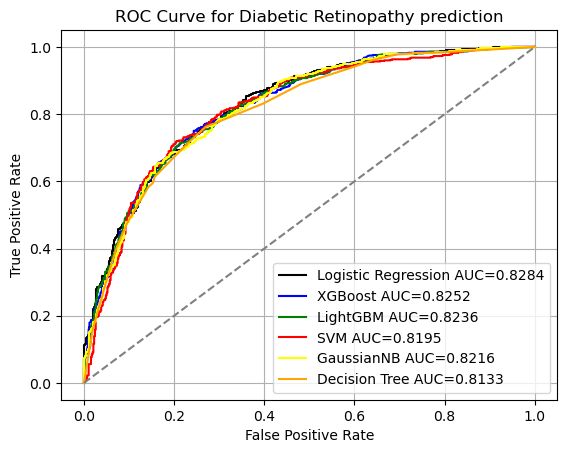

In [76]:
###Plot Roc curve
plt.plot(fpr1,tpr1,color='black',label=f'Logistic Regression AUC={auc_scores[0]}')
plt.plot(fpr2,tpr2,color='blue',label=f'XGBoost AUC={auc_scores[1]}')
plt.plot(fpr3,tpr3,color='green',label=f'LightGBM AUC={auc_scores[2]}')
plt.plot(fpr4,tpr4,color='red',label=f'SVM AUC={auc_scores[3]}')
plt.plot(fpr5,tpr5,color='yellow',label=f'GaussianNB AUC={auc_scores[4]}')
plt.plot(fpr6,tpr6,color='orange',label=f'Decision Tree AUC={auc_scores[5]}')

## random classifier line
plt.plot([0,1],[0,1],linestyle='--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetic Retinopathy prediction')
plt.legend()
plt.grid()


In [77]:
### Creating dataframes with all the metrics
models_dict = {
    "Logistic Regression": (log_reg, X_test),
    "XGBoost": (xgb, X_test),
    "LightGBM": (lgb, X_test),
    "SVM ": (svm_class, X_test),
    "NavieBayes": (gau_nb, X_test),
    "Decision Tree":(d_tree,X_test)
}

comparison_results = {}

for name, (model, X_eval) in models_dict.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    comparison_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

comparison_df = pd.DataFrame(comparison_results).T.round(4)
comparison_df

,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
Logistic Regression,0.7467,0.7610,0.7488,0.7443,0.7548,0.8284
XGBoost,0.7517,0.7659,0.7536,0.7496,0.7597,0.8252
LightGBM,0.7392,0.7445,0.7600,0.7165,0.7522,0.8236
SVM,0.7475,0.7508,0.7712,0.7217,0.7609,0.8195
NavieBayes,0.7367,0.7678,0.7088,0.7670,0.7371,0.8216
Decision Tree,0.7467,0.7544,0.7616,0.7304,0.7580,0.8133


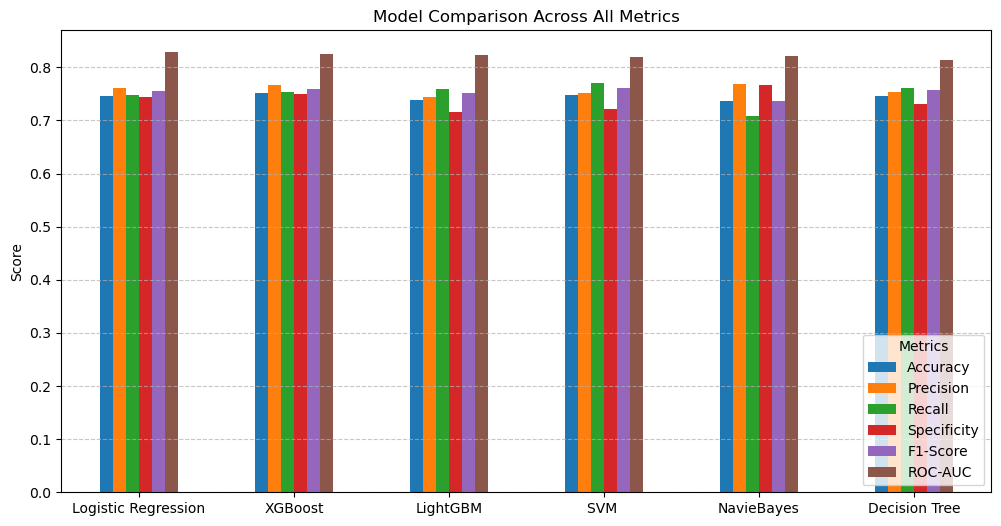

In [78]:
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison Across All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metrics',loc='lower right')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

In [79]:
best_model_name = comparison_df["ROC-AUC"].idxmax()
print("Best model based on ROC-AUC:", best_model_name)
print(comparison_df.loc[best_model_name])

Best model based on ROC-AUC: Logistic Regression
Accuracy       0.7467
Precision      0.7610
Recall         0.7488
Specificity    0.7443
F1-Score       0.7548
ROC-AUC        0.8284
Name: Logistic Regression, dtype: float64


### Model Deployment

In [80]:
from pickle import dump

In [87]:
dump(log_reg, open("log_reg.pkl",'wb'))

In [89]:
dump(scaler,open('scaler.pkl','wb'))